2025-03-19 12:17:54,975 - INFO - Loading spectral data...
2025-03-19 12:17:54,977 - INFO - Processing Lab data...
2025-03-19 12:17:54,977 - INFO - Normalizing Lab data...
2025-03-19 12:17:54,979 - INFO - Training the model...
2025-03-19 12:17:54,981 - INFO - Epoch 1/1000 - MSE Loss: 0.40788254141807556
2025-03-19 12:17:54,982 - INFO - Epoch 2/1000 - MSE Loss: 0.24809469282627106
2025-03-19 12:17:54,984 - INFO - Epoch 3/1000 - MSE Loss: 0.19112896919250488
2025-03-19 12:17:54,985 - INFO - Epoch 4/1000 - MSE Loss: 0.1189994141459465
2025-03-19 12:17:54,987 - INFO - Epoch 5/1000 - MSE Loss: 0.06418044120073318
2025-03-19 12:17:54,988 - INFO - Epoch 6/1000 - MSE Loss: 0.04540450498461723
2025-03-19 12:17:54,989 - INFO - Epoch 7/1000 - MSE Loss: 0.05132930353283882
2025-03-19 12:17:54,991 - INFO - Epoch 8/1000 - MSE Loss: 0.025551943108439445
2025-03-19 12:17:54,992 - INFO - Epoch 9/1000 - MSE Loss: 0.03173288330435753
2025-03-19 12:17:54,993 - INFO - Epoch 10/1000 - MSE Loss: 0.02912756241

Mean ΔE2000 Error: 3.9003200180332374
Max ΔE2000 Error: 13.403963526880531


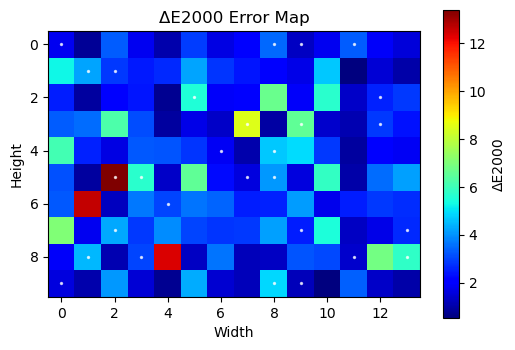

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_lab(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data directly to Lab.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)

    # Convert XYZ to Lab
    lab = color.xyz2lab(xyz)
    return lab

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process Lab data
###########################################
logging.info('Processing Lab data...')
lab_input = process_lab(cube_data, wl_input, ill, CMFs)   
lab_ref   = process_lab(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data in Lab space
###########################################
logging.info('Normalizing Lab data...')
lab_input_2d = lab_input.reshape(-1, lab_input.shape[-1])
lab_ref_2d   = lab_ref.reshape(-1, lab_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(lab_input_2d)
Y_norm = scaler_ref.fit_transform(lab_ref_2d)

X_full = X_norm.reshape(lab_input.shape)
Y_full = Y_norm.reshape(lab_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define the MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = SimpleMLP(input_size=3, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# 6. Training loop (using MSE loss in Lab space)
###########################################
epochs = 1000
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# 7. Apply correction and evaluate with ΔE2000
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_lab = scaler_ref.inverse_transform(corrected_flat)
corrected_lab_image = corrected_lab.reshape(lab_ref.shape)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab_image)

# Compute mean ΔE2000 error
# Flatten the error map for indexing
error_map_flat = error_map.reshape(-1)
# Extract only test-set errors using precomputed test_indices
test_error_values = error_map_flat[test_indices]
# Compute mean & max ΔE2000 error for the test set
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)
print("Mean ΔE2000 Error:", mean_error_test)
print("Max ΔE2000 Error:", max_error_test)

# Get train set pixel positions in the image
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()
